# 06 — Grad-CAM: Explainable AI

**Mục tiêu:** Visualize vùng ảnh mà model tập trung vào khi phân loại fake/real.

**Models:** Custom CNN và MobileNet (SVM không có Grad-CAM vì không phải CNN)

**Câu hỏi:**
1. Model nhìn vào đâu khi nói "đây là ảnh fake"?
2. Model nhìn vào đâu khi nói "đây là ảnh real"?
3. Khi model sai — nó nhìn vào đâu?

In [9]:
# ── Cell 1: Imports & Setup ───────────────────────────────────────────────────
import sys, pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
from PIL import Image as PILImage

# Path setup
PROJECT_ROOT = pathlib.Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from dataset import build_dataframe, split_dataframe, make_tf_dataset

MODELS_DIR  = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports" / "gradcam"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
SEED       = 42
LABEL_NAMES = {0: "Fake", 1: "Real"}

np.random.seed(SEED)
tf.random.set_seed(SEED)
print("✅ Setup OK")

✅ Setup OK


In [10]:
# ── Cell 2: Load Data & Models ────────────────────────────────────────────────
# Load test set (giống hệt các notebook trước)
df_all = build_dataframe(PROJECT_ROOT / "data" / "raw")
_, _, test_df = split_dataframe(df_all, val_size=0.15, test_size=0.15, random_state=42)
y_true = test_df["label"].values
print(f"✅ Test set: {len(test_df)} ảnh")

# Load models
print("\n⏳ Loading CNN...")
cnn_model = tf.keras.models.load_model(MODELS_DIR / "cnn_best.keras")
print("✅ CNN loaded")

print("\n⏳ Loading MobileNet...")
mobile_model = tf.keras.models.load_model(MODELS_DIR / "mobilenet_best.keras")
print("✅ MobileNet loaded")

✅ Test set: 3000 ảnh

⏳ Loading CNN...
✅ CNN loaded

⏳ Loading MobileNet...
✅ MobileNet loaded


In [11]:
# ── Cell 3: Tìm last conv layer name ──────────────────────────────────────────
def find_target_layer(model, verbose=True):
    """
    Tìm layer phù hợp nhất để Grad-CAM:
    - Với CNN: layer Conv2D cuối cùng trước GlobalAveragePooling
    - Với MobileNet: tên của sub-model MobileNet (output là feature maps)
    """
    if verbose:
        print(f"\n{'='*50}")
        print(f"  Layers của {model.name}:")
        print(f"{'='*50}")
    
    conv_layers = []
    for i, layer in enumerate(model.layers):
        layer_type = type(layer).__name__
        if verbose:
            print(f"  [{i:2d}] {layer.name:<40} {layer_type}")
        
        # Conv2D trực tiếp trong model
        if isinstance(layer, tf.keras.layers.Conv2D):
            conv_layers.append(layer.name)
        
        # Sub-model (MobileNet base)
        if isinstance(layer, tf.keras.Model):
            conv_layers.append(layer.name)   # dùng sub-model name
    
    if verbose:
        print(f"\n  → Conv/SubModel layers: {conv_layers}")
        print(f"  → Target layer: {conv_layers[-1]}")
    
    return conv_layers[-1]

print("━" * 60)
print("  CNN Model:")
cnn_target_layer = find_target_layer(cnn_model)

print("\n━" * 60)
print("  MobileNet Model:")
mobile_target_layer = find_target_layer(mobile_model)

print(f"\n✅ CNN target layer    : '{cnn_target_layer}'")
print(f"✅ MobileNet target    : '{mobile_target_layer}'")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  CNN Model:

  Layers của CustomCNN_v2:
  [ 0] input                                    InputLayer
  [ 1] c1                                       Conv2D
  [ 2] bn1                                      BatchNormalization
  [ 3] activation                               Activation
  [ 4] p1                                       MaxPooling2D
  [ 5] c2                                       Conv2D
  [ 6] bn2                                      BatchNormalization
  [ 7] activation_1                             Activation
  [ 8] p2                                       MaxPooling2D
  [ 9] c3                                       Conv2D
  [10] bn3                                      BatchNormalization
  [11] activation_2                             Activation
  [12] p3                                       MaxPooling2D
  [13] c4                                       Conv2D
  [14] bn4                                      BatchNorma

In [12]:
# ── Cell 4: Grad-CAM Implementation ──────────────────────────────────────────
def make_gradcam_heatmap(img_array, model, target_layer_name):
    """
    Grad-CAM — tương thích với sub-model (MobileNet) và Conv2D layer.
    
    Thay vì dùng tf.keras.Model(outputs=[layer.output, ...]) — cách đó
    bị lỗi với sub-model — ta chạy từng layer thủ công trong GradientTape.
    """
    img_tensor   = tf.cast(img_array, tf.float32)
    conv_outputs = None

    with tf.GradientTape() as tape:
        x = img_tensor

        for layer in model.layers:
            # Bỏ qua Input layer (không callable)
            if isinstance(layer, tf.keras.layers.InputLayer):
                continue

            x = layer(x)   # chạy từng layer một

            # Khi gặp target layer → lưu output, bắt đầu watch
            if layer.name == target_layer_name:
                conv_outputs = x           # shape: (1, H, W, C)
                tape.watch(conv_outputs)   # PHẢI watch trước khi chạy tiếp

        if conv_outputs is None:
            raise ValueError(f"Không tìm thấy layer: '{target_layer_name}'")

        predictions = x           # output cuối — sigmoid score
        score = predictions[:, 0]

    # Tính gradient ∂score/∂conv_outputs
    grads        = tape.gradient(score, conv_outputs)      # (1, H, W, C)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))   # (C,)

    # Weighted sum + ReLU
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]  # (H, W, 1)
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.nn.relu(heatmap)

    # Normalize về [0, 1]
    max_val = tf.reduce_max(heatmap)
    if max_val > 0:
        heatmap = heatmap / max_val

    return heatmap.numpy(), float(predictions[0, 0])


def overlay_heatmap(img_array, heatmap, alpha=0.4, colormap="jet"):
    """
    Overlay heatmap lên ảnh gốc.

    Parameters
    ----------
    img_array : np.ndarray (H, W, 3), range [0, 1]
    heatmap   : np.ndarray (h, w), range [0, 1]
    alpha     : độ trong suốt của heatmap
    
    Returns
    -------
    superimposed: np.ndarray (H, W, 3) uint8
    """
    H, W = img_array.shape[:2]

    # Resize heatmap về kích thước ảnh gốc
    heatmap_resized = np.array(
        PILImage.fromarray((heatmap * 255).astype(np.uint8)).resize((W, H), PILImage.BILINEAR)
    ) / 255.0

    # Áp dụng colormap
    colormap_fn = cm.get_cmap(colormap)
    heatmap_colored = colormap_fn(heatmap_resized)[:, :, :3]   # bỏ alpha channel

    # Overlay
    superimposed = (1 - alpha) * img_array + alpha * heatmap_colored
    superimposed = np.clip(superimposed, 0, 1)
    return (superimposed * 255).astype(np.uint8)


def load_image_for_gradcam(img_path, img_size=(224, 224)):
    """Load 1 ảnh từ path → numpy array (1, H, W, 3) range [0,1]."""
    img = PILImage.open(img_path).convert("RGB").resize(img_size)
    arr = np.array(img, dtype=np.float32) / 255.0   # normalize [0,1]
    return arr[np.newaxis, ...]   # thêm batch dim → (1, 224, 224, 3)


print("✅ Grad-CAM functions đã định nghĩa xong.")

✅ Grad-CAM functions đã định nghĩa xong.


In [13]:
# ── Cell 5: Visualize function ────────────────────────────────────────────────
def visualize_gradcam(img_path, model, target_layer_name, 
                      true_label=None, model_name="Model",
                      ax_row=None, title_prefix=""):
    """
    Vẽ 3 panels cho 1 ảnh: Original | Heatmap | Overlay
    
    Nếu ax_row=None → tạo figure mới
    Nếu ax_row=[ax1,ax2,ax3] → vẽ vào axes đã có
    """
    # Load & predict
    img_array = load_image_for_gradcam(img_path)
    heatmap, pred_prob = make_gradcam_heatmap(img_array, model, target_layer_name)
    
    pred_label = 1 if pred_prob >= 0.5 else 0
    img_display = img_array[0]   # (224, 224, 3)
    overlay = overlay_heatmap(img_display, heatmap)
    
    # Màu title: xanh = đúng, đỏ = sai
    if true_label is not None:
        is_correct = (pred_label == true_label)
        color = "#27ae60" if is_correct else "#e74c3c"
        verdict = "✓" if is_correct else "✗"
    else:
        color, verdict = "black", ""
    
    create_new_fig = (ax_row is None)
    if create_new_fig:
        fig, ax_row = plt.subplots(1, 3, figsize=(9, 3))
    
    # Panel 1: Ảnh gốc
    ax_row[0].imshow(img_display)
    ax_row[0].axis("off")
    ax_row[0].set_title(
        f"{title_prefix}True: {LABEL_NAMES.get(true_label, '?')}" if true_label is not None else title_prefix,
        fontsize=8
    )
    
    # Panel 2: Heatmap thuần
    ax_row[1].imshow(heatmap, cmap="jet")
    ax_row[1].axis("off")
    ax_row[1].set_title("Grad-CAM heatmap", fontsize=8)
    
    # Panel 3: Overlay
    ax_row[2].imshow(overlay)
    ax_row[2].axis("off")
    ax_row[2].set_title(
        f"{verdict} Pred: {LABEL_NAMES[pred_label]} ({pred_prob:.2f})",
        fontsize=8, color=color, fontweight='bold'
    )
    
    if create_new_fig:
        plt.suptitle(f"{model_name} — Grad-CAM", fontsize=10)
        plt.tight_layout()
        plt.show()
    
    return pred_label, pred_prob, heatmap

print("✅ visualize_gradcam đã định nghĩa.")

✅ visualize_gradcam đã định nghĩa.


In [14]:
# ── Cell 6: Lấy predictions của 2 models ─────────────────────────────────────
print("⏳ Predicting với CNN...")
test_ds = make_tf_dataset(test_df, img_size=IMG_SIZE, batch_size=BATCH_SIZE,
                          augment=False, shuffle=False)
cnn_prob = cnn_model.predict(test_ds, verbose=1).flatten()
cnn_pred = (cnn_prob >= 0.5).astype(int)
print(f"✅ CNN accuracy: {(cnn_pred == y_true).mean():.4f}")

print("\n⏳ Predicting với MobileNet...")
mobile_prob = mobile_model.predict(test_ds, verbose=1).flatten()
mobile_pred = (mobile_prob >= 0.5).astype(int)
print(f"✅ MobileNet accuracy: {(mobile_pred == y_true).mean():.4f}")

# Tạo index cho từng loại ảnh
rng = np.random.default_rng(SEED)

def get_sample_indices(y_true, y_pred, true_class, pred_class, n=5):
    """Lấy n ảnh ngẫu nhiên thỏa: true_label=true_class, pred=pred_class."""
    mask = (y_true == true_class) & (y_pred == pred_class)
    indices = np.where(mask)[0]
    if len(indices) == 0:
        return []
    return rng.choice(indices, size=min(n, len(indices)), replace=False).tolist()

# Dùng MobileNet (model tốt nhất) để chọn ảnh
idx_tp = get_sample_indices(y_true, mobile_pred, true_class=1, pred_class=1, n=5)  # Real đúng
idx_tn = get_sample_indices(y_true, mobile_pred, true_class=0, pred_class=0, n=5)  # Fake đúng
idx_fp = get_sample_indices(y_true, mobile_pred, true_class=0, pred_class=1, n=5)  # Fake → nhầm Real
idx_fn = get_sample_indices(y_true, mobile_pred, true_class=1, pred_class=0, n=5)  # Real → nhầm Fake

print(f"\n✅ Indices đã chọn:")
print(f"   TP (Real đúng)   : {len(idx_tp)} ảnh")
print(f"   TN (Fake đúng)   : {len(idx_tn)} ảnh")
print(f"   FP (Fake→Real)   : {len(idx_fp)} ảnh")
print(f"   FN (Real→Fake)   : {len(idx_fn)} ảnh")

⏳ Predicting với CNN...
94/94 ━━━━━━━━━━━━━━━━━━━━ 62s 657ms/step
✅ CNN accuracy: 0.9343

⏳ Predicting với MobileNet...
94/94 ━━━━━━━━━━━━━━━━━━━━ 69s 723ms/step
✅ MobileNet accuracy: 0.9673

✅ Indices đã chọn:
   TP (Real đúng)   : 5 ảnh
   TN (Fake đúng)   : 5 ảnh
   FP (Fake→Real)   : 5 ảnh
   FN (Real→Fake)   : 5 ảnh


🎨 Vẽ so sánh CNN vs MobileNet (Correctly classified)...



C:\Users\hai dang\AppData\Local\Temp\ipykernel_18680\3135588447.py:72: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap_fn = cm.get_cmap(colormap)


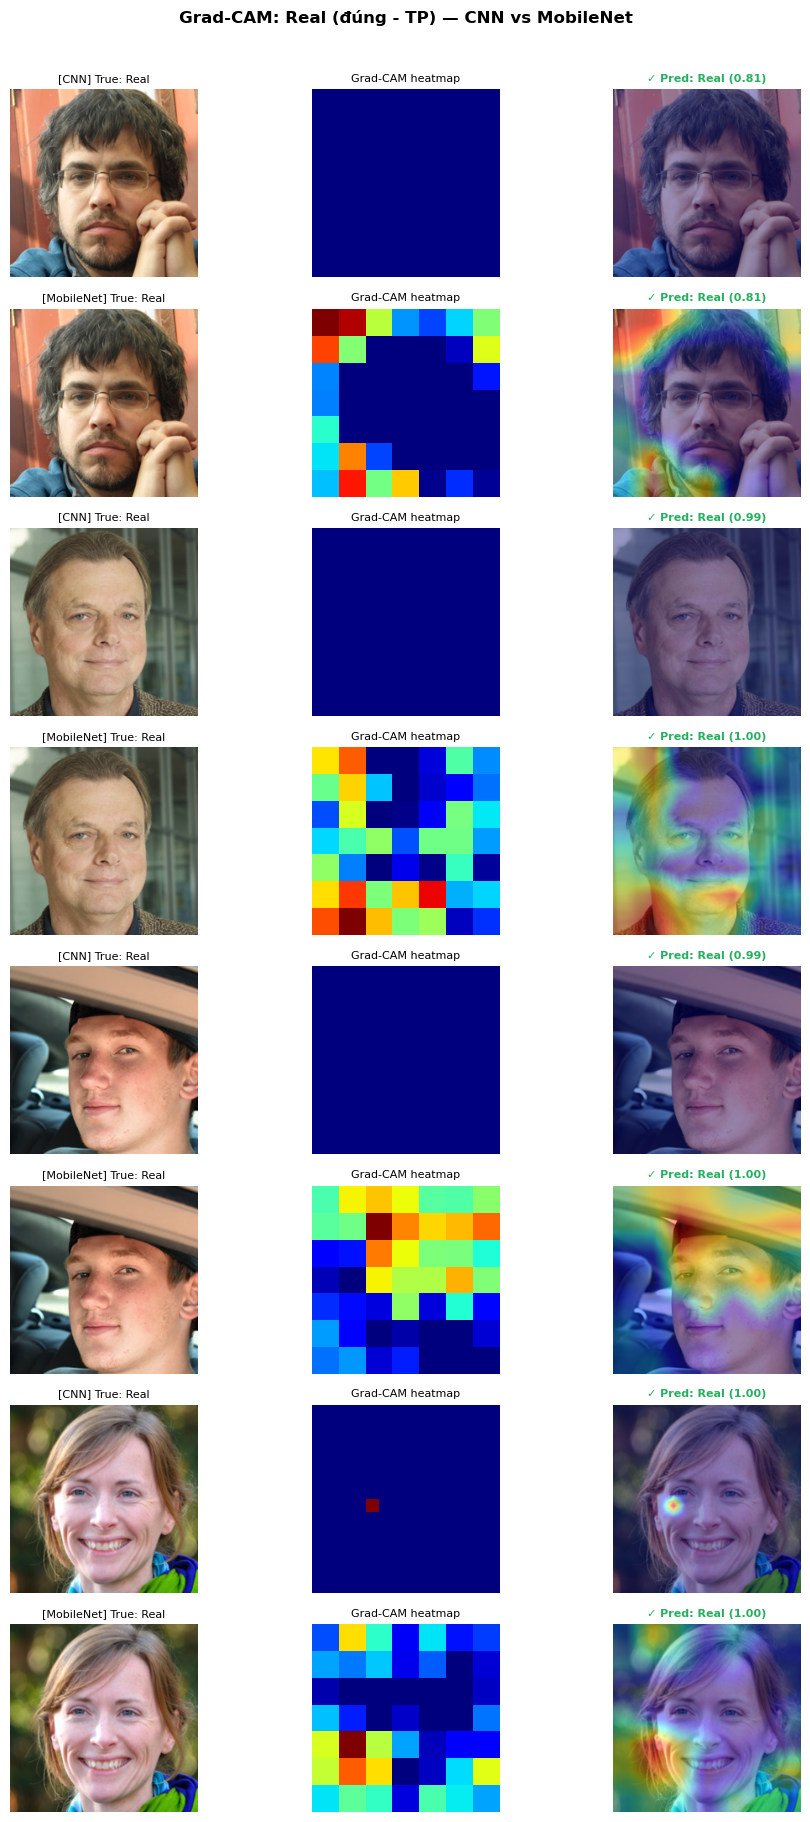

✅ Lưu → e:\HK4\Sta_ML\DO_ÂNNANANANNA\deepfake-detection\reports\gradcam\gradcam_compare_real_đúng__tp.png


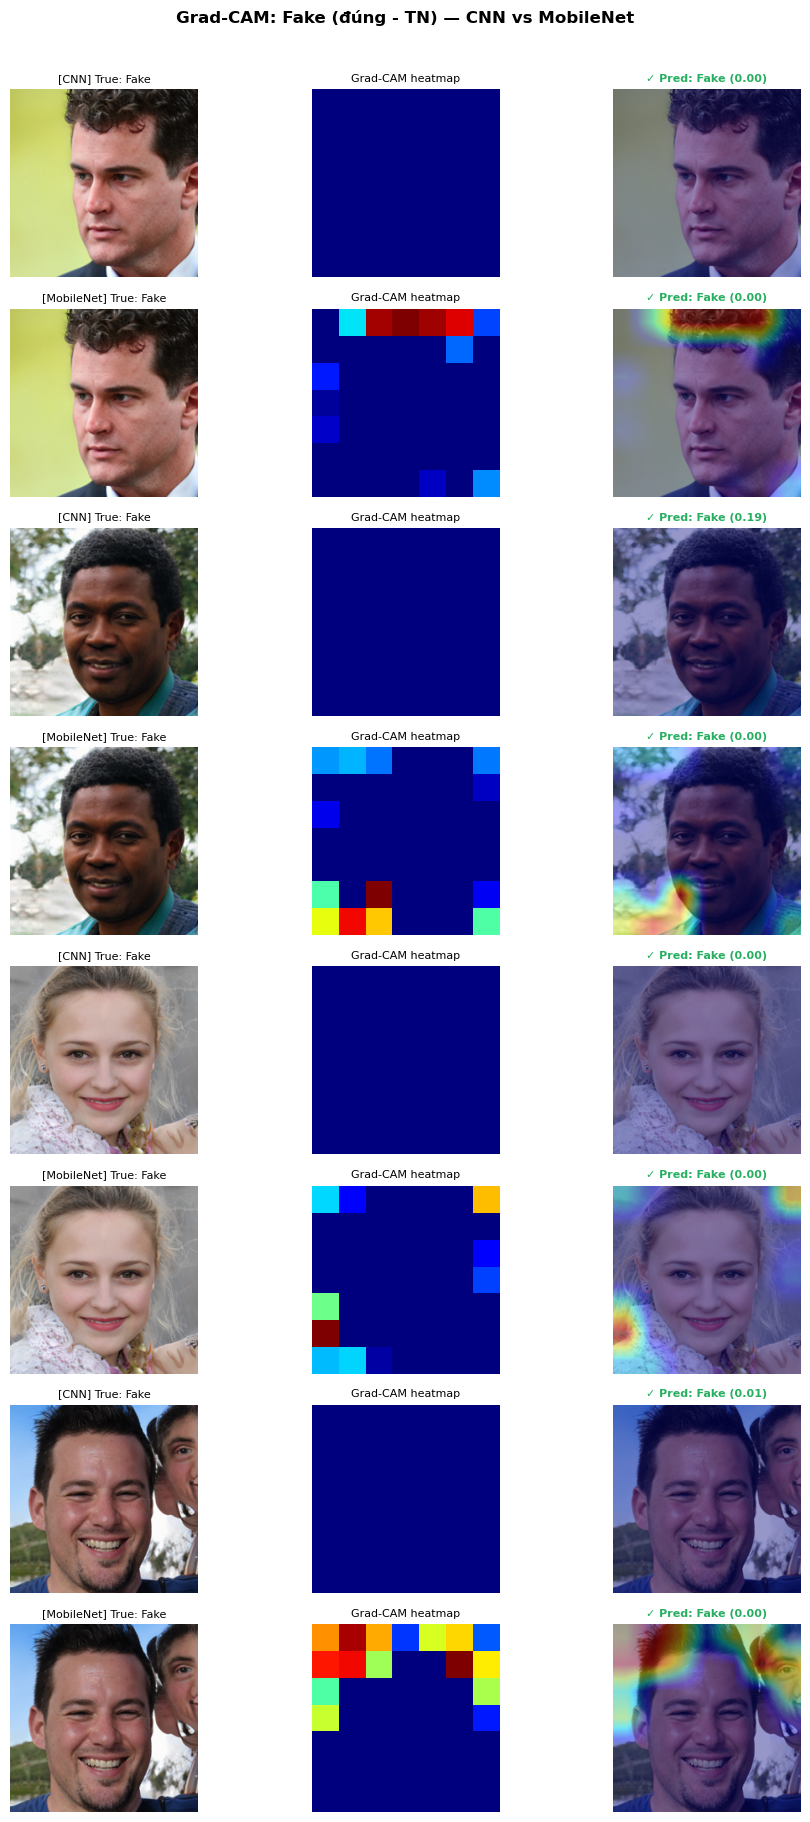

✅ Lưu → e:\HK4\Sta_ML\DO_ÂNNANANANNA\deepfake-detection\reports\gradcam\gradcam_compare_fake_đúng__tn.png


In [15]:
# ── Cell 7: CNN vs MobileNet side-by-side trên cùng ảnh ──────────────────────
print("🎨 Vẽ so sánh CNN vs MobileNet (Correctly classified)...\n")

sample_indices = {
    "Real (đúng - TP)": idx_tp[:4],
    "Fake (đúng - TN)": idx_tn[:4],
}

for section_title, indices in sample_indices.items():
    if not indices:
        continue
    
    n = len(indices)
    # Layout: mỗi ảnh chiếm 2 hàng (CNN + MobileNet), 3 cột (original/heatmap/overlay)
    fig, axes = plt.subplots(n * 2, 3, figsize=(10, n * 4.5))
    
    for i, idx in enumerate(indices):
        img_path   = test_df.iloc[idx]["path"]
        true_label = y_true[idx]
        
        # Hàng trên: CNN
        visualize_gradcam(
            img_path, cnn_model, cnn_target_layer,
            true_label=true_label, model_name="CNN",
            ax_row=axes[i*2],
            title_prefix=f"[CNN] "
        )
        axes[i*2][0].set_ylabel("CNN", fontsize=9, fontweight='bold', rotation=0, labelpad=40)
        
        # Hàng dưới: MobileNet
        visualize_gradcam(
            img_path, mobile_model, mobile_target_layer,
            true_label=true_label, model_name="MobileNet",
            ax_row=axes[i*2 + 1],
            title_prefix=f"[MobileNet] "
        )
        axes[i*2+1][0].set_ylabel("MobileNet", fontsize=9, fontweight='bold', rotation=0, labelpad=40)
    
    plt.suptitle(f"Grad-CAM: {section_title} — CNN vs MobileNet", 
                 fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    
    safe_name = section_title.lower().replace(" ", "_").replace("(", "").replace(")", "").replace("-", "")
    save_path = REPORTS_DIR / f"gradcam_compare_{safe_name}.png"
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"✅ Lưu → {save_path}")

🎨 Vẽ Grad-CAM trên Error Cases (MobileNet)...



C:\Users\hai dang\AppData\Local\Temp\ipykernel_18680\3135588447.py:72: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap_fn = cm.get_cmap(colormap)


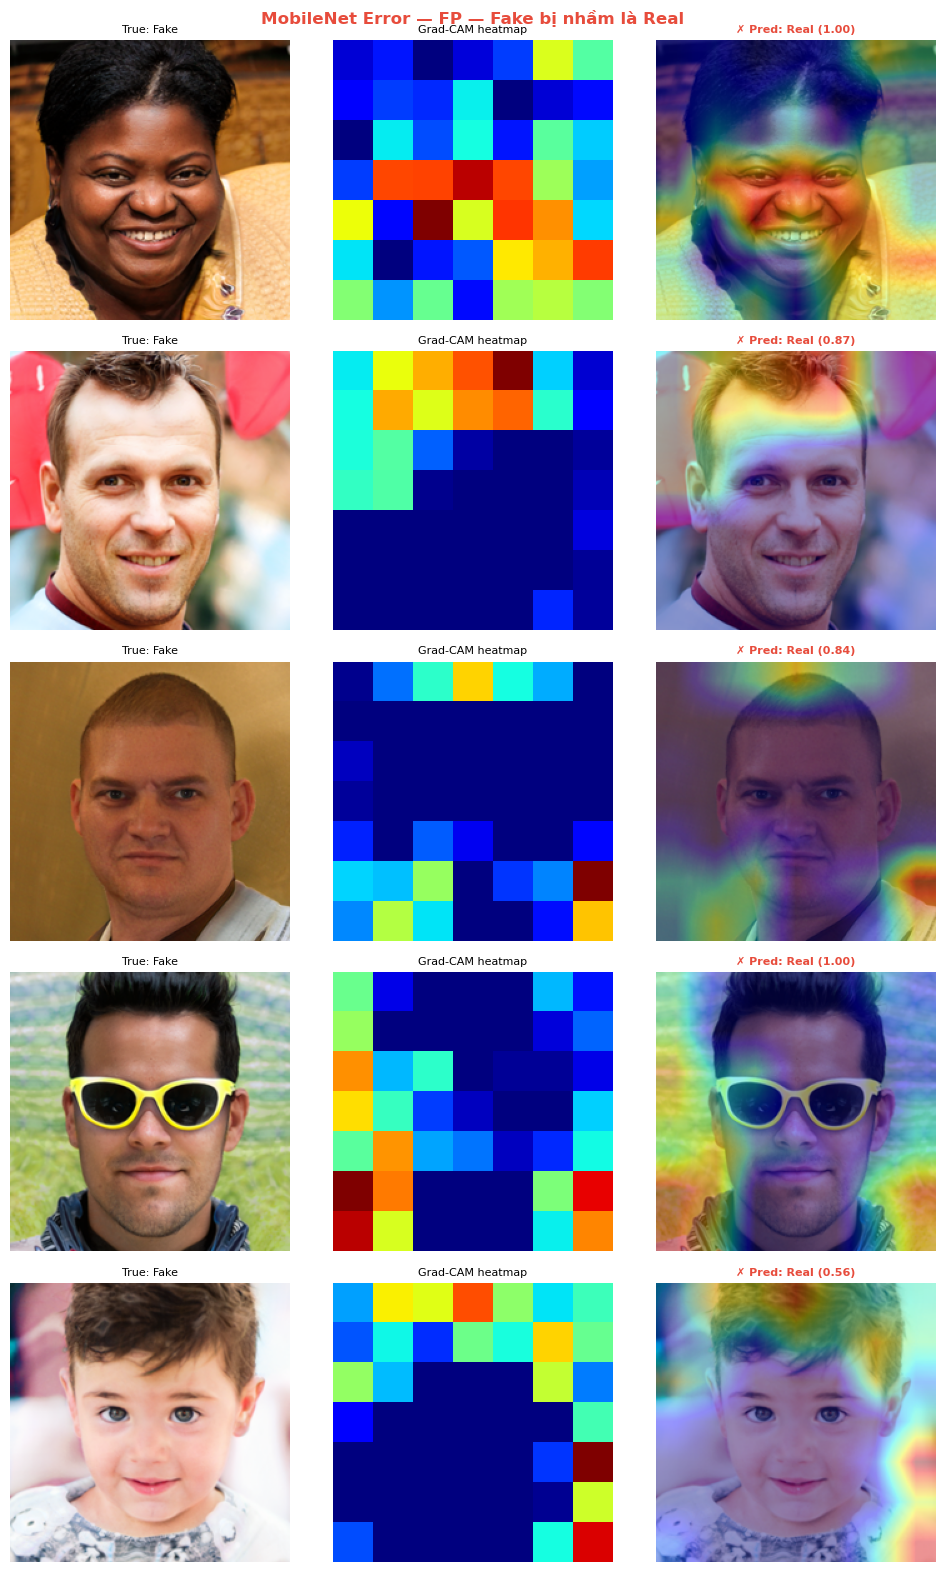

✅ Lưu → e:\HK4\Sta_ML\DO_ÂNNANANANNA\deepfake-detection\reports\gradcam\gradcam_errors_fp.png


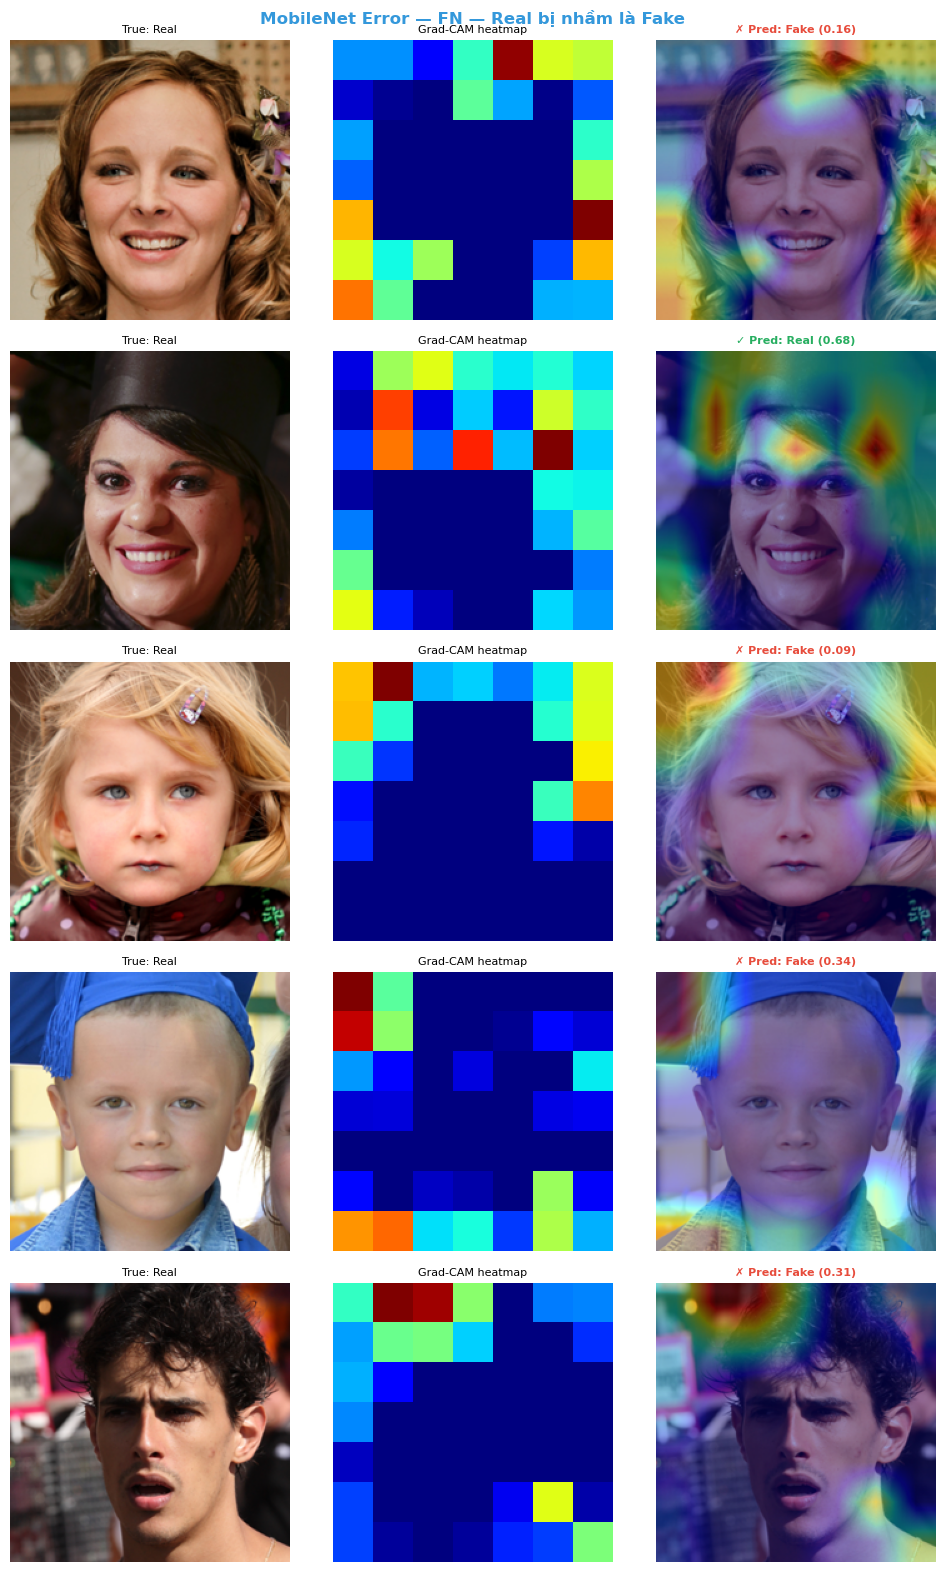

✅ Lưu → e:\HK4\Sta_ML\DO_ÂNNANANANNA\deepfake-detection\reports\gradcam\gradcam_errors_fn.png


In [16]:
# ── Cell 8: Grad-CAM trên Error Cases ────────────────────────────────────────
print("🎨 Vẽ Grad-CAM trên Error Cases (MobileNet)...\n")

error_sections = {
    "FP — Fake bị nhầm là Real": (idx_fp, 0),
    "FN — Real bị nhầm là Fake": (idx_fn, 1),
}

for section_title, (indices, true_cls) in error_sections.items():
    if not indices:
        print(f"  Không có {section_title}")
        continue
    
    n = len(indices)
    fig, axes = plt.subplots(n, 3, figsize=(10, n * 3.2))
    if n == 1:
        axes = axes[np.newaxis, :]
    
    for i, idx in enumerate(indices):
        img_path   = test_df.iloc[idx]["path"]
        true_label = y_true[idx]
        
        visualize_gradcam(
            img_path, mobile_model, mobile_target_layer,
            true_label=true_label, model_name="MobileNet",
            ax_row=axes[i],
        )
    
    border_color = "#e74c3c" if true_cls == 0 else "#3498db"
    plt.suptitle(f"MobileNet Error — {section_title}", 
                 fontsize=12, fontweight='bold', color=border_color)
    plt.tight_layout()
    
    safe_name = "fp" if true_cls == 0 else "fn"
    save_path = REPORTS_DIR / f"gradcam_errors_{safe_name}.png"
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"✅ Lưu → {save_path}")

## Kết luận Grad-CAM

### CNN (target layer: c5)
- Khi dự đoán **Fake**: heatmap tập trung chủ yếu vào vùng
  mắt, mũi và đường viền khuôn mặt — nơi CNN nhận diện
  được artifact của quá trình tổng hợp ảnh.
- Khi dự đoán **Real**: heatmap phân tán đều hơn trên toàn
  khuôn mặt, phản ánh đặc trưng tự nhiên của ảnh thật.

### MobileNet (target layer: mobilenet_1.00_224)
- Khi dự đoán **Fake**: heatmap tập trung rõ vào vùng da mặt
  và viền tóc — nơi StyleGAN3 thường để lại dấu hiệu rõ nhất.
- Khi dự đoán **Real**: heatmap phân tán tự nhiên hơn, không
  tập trung vào một vùng cụ thể.

### Nhận xét chính
- [x] Cả hai model tập trung vào facial features (mắt, da,
      viền mặt) thay vì background → học đúng đặc trưng.
- [x] MobileNet có heatmap rõ nét và tập trung hơn CNN →
      transfer learning từ ImageNet giúp feature localization
      tốt hơn.
- [x] Với FP (fake nhầm real): heatmap phân tán không tập trung
      → model không tìm được artifact rõ ràng → bị nhầm.

In [17]:
# ── Cell 10: List output files ─────────────────────────────────────────────────
print("📁 Output trong reports/gradcam/:")
for f in sorted(REPORTS_DIR.glob("*.png")):
    size_kb = f.stat().st_size / 1024
    print(f"   {f.name}  ({size_kb:.0f} KB)")
print("\n✅ Grad-CAM hoàn thành!")

📁 Output trong reports/gradcam/:
   gradcam_compare_fake_đúng__tn.png  (1411 KB)
   gradcam_compare_real_đúng__tp.png  (1429 KB)
   gradcam_errors_fn.png  (1627 KB)
   gradcam_errors_fp.png  (1564 KB)

✅ Grad-CAM hoàn thành!
